# CCGT NPV simulation

Run the CCGT electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import simulate_ccgt_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_ccgt_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,ccgt,1000000.0,4650.0,215.053763,215053.763441,1254.275634,24.270882,4.733201,1.652581,...,94070000.0,5.219545e+06,4.733201e+06,6.857330e+07,2.685272e+07,-1.130877e+07,-3.904553e+08,25000000.0,-15.618212,-1.561821e-05
1,1,ccgt,1000000.0,4650.0,215.053763,215053.763441,1120.042397,21.643843,5.523013,1.679538,...,94070000.0,4.654590e+06,5.523013e+06,7.757350e+07,2.714887e+07,-2.082997e+07,-4.632246e+08,25000000.0,-18.528985,-1.852899e-05
2,2,ccgt,1000000.0,4650.0,215.053763,215053.763441,1010.996747,17.501272,5.483781,1.694798,...,94070000.0,3.763715e+06,5.483781e+06,6.308999e+07,2.698419e+07,-5.251672e+06,-2.734791e+08,25000000.0,-10.939163,-1.093916e-05
3,3,ccgt,1000000.0,4650.0,215.053763,215053.763441,1185.277384,19.440882,4.468317,1.664284,...,94070000.0,4.180835e+06,4.468317e+06,3.452235e+07,2.629700e+07,2.460150e+07,7.717101e+06,25000000.0,0.308684,3.086841e-07
4,4,ccgt,1000000.0,4650.0,215.053763,215053.763441,1097.136270,18.627441,4.829076,1.650379,...,94070000.0,4.005901e+06,4.829076e+06,1.235485e+08,2.695677e+07,-6.527027e+07,-9.326888e+08,25000000.0,-37.307550,-3.730755e-05


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-320.260711,-12.810428,-0.000013
std,252.475758,10.099030,0.000010
min,-1233.697313,-49.347893,-0.000049
5%,-776.153462,-31.046138,-0.000031
50%,-294.549966,-11.781999,-0.000012
95%,47.413538,1.896542,0.000002
max,205.432072,8.217283,0.000008


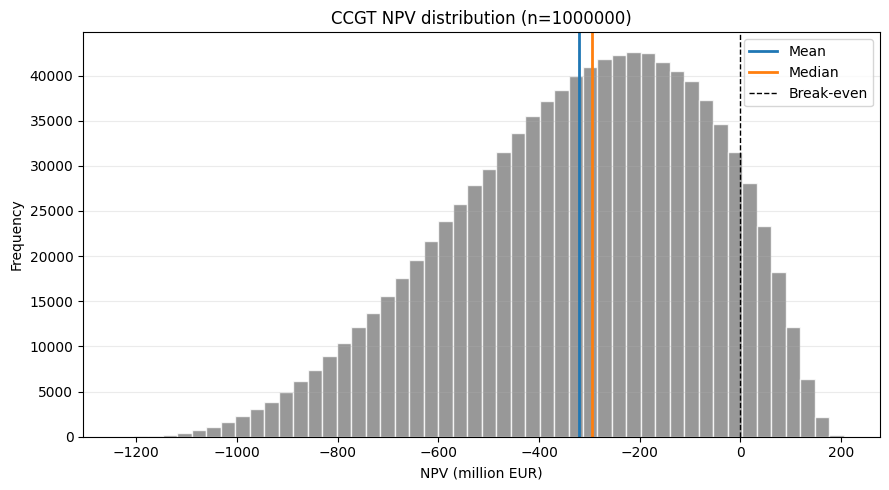

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


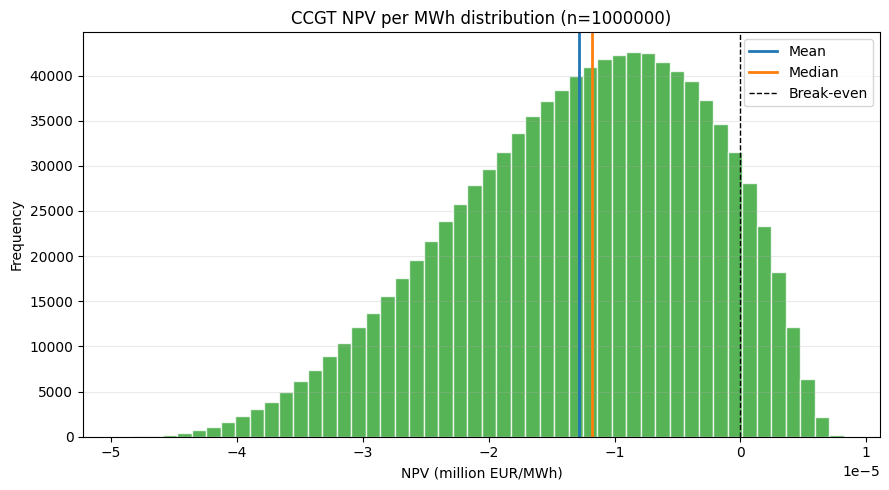

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         4.444973
annual_variable_opex_eur      5.166461
annual_fuel_cost_eur         65.343611
annual_emissions_cost_eur    26.960088
annual_net_cash_flow_eur     -7.845133
Name: Mean annual value, million EUR, dtype: float64